<a href="https://colab.research.google.com/github/GustavoABrandao/Projeto---IA-Facens/blob/main/Projeto%20Big%20Data_tentativa%20de%20melhorar%20modelo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [131]:
# Importando bibliotecas necessárias
from pyspark.sql import SparkSession
from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline
from pyspark.sql.functions import expr
from pyspark.sql.functions import col, regexp_extract
from pyspark.sql.functions import expr, current_date, year as spark_year
import matplotlib.pyplot as plt
from pyspark.sql.types import IntegerType
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
import numpy as np
import matplotlib.pyplot as plt

spark = SparkSession.builder \
    .appName("PySpark Docker Example") \
    .getOrCreate()

In [164]:
dataframe = spark.read.csv("/content/vehicles.csv", header=True, inferSchema=True)
num_linhas = dataframe.count()
print(f"Número de linhas no DataFrame: {num_linhas}")

Número de linhas no DataFrame: 441802


In [133]:
dataframe.show(50)

+----------+--------------------+--------------------+--------------------+-----+----+------------+--------------------+---------+-----------+-----+--------+------------+------------+-----------------+-----+---------+------+-----------+--------------------+--------------------+------+-----+-------+----------+--------------------+
|        id|                 url|              region|          region_url|price|year|manufacturer|               model|condition|  cylinders| fuel|odometer|title_status|transmission|              VIN|drive|     size|  type|paint_color|           image_url|         description|county|state|    lat|      long|        posting_date|
+----------+--------------------+--------------------+--------------------+-----+----+------------+--------------------+---------+-----------+-----+--------+------------+------------+-----------------+-----+---------+------+-----------+--------------------+--------------------+------+-----+-------+----------+--------------------+
|722

In [165]:
df = dataframe

# Regex mais flexível: ignora o que não for número/ponto/sinal de menos
# Removemos o sinal de negativo de colunas que não podem ser negativas (preço, ano, km)
df = df.withColumn(
    "year",
    expr("try_cast(regexp_replace(year, '[^0-9]', '') as double)")
)

df = df.withColumn(
    "price",
    expr("try_cast(regexp_replace(price, '[^0-9.]', '') as double)")
)

df = df.withColumn(
    "odometer",
    expr("try_cast(regexp_replace(odometer, '[^0-9.]', '') as double)")
)

df = df.withColumn(
    "lat",
    expr("try_cast(regexp_replace(lat, '[^0-9.-]', '') as double)")
)

df = df.withColumn(
    "long",
    expr("try_cast(regexp_replace(long, '[^0-9.-]', '') as double)")
)

df = df.withColumn(
    "car_age",
    spark_year(current_date()) - col("year")
)
# Remoção de colunas
df = df.drop(
    "id", "url", "region_url", "VIN",
    "image_url", "description", "county",
    "posting_date", "size"
)

In [135]:
# =========================
# 2. DROP E FILTROS (MENOS AGRESSIVO)
# =========================

# DICA: Removi lat e long do dropna. Se não tiver localização, a gente mantém o carro!
df = df.dropna(subset=["price", "year", "odometer"])

# Filtros de sanidade
df = df.filter(
    (col("price") >= 1000.0) & (col("price") < 50000.0) &
    (col("year") > 1995.0) & (col("year") <= 2026.0)
)


# VERIFICAÇÃO INTERMEDIÁRIA
contagem = df.count()
print(f"Registros após limpeza inicial: {contagem}")

if contagem > 0:
    # 3. CACHE E ESTATÍSTICA
    df.cache()

    for c in ["price", "odometer"]:
        # Verificamos se há dados suficientes para calcular quantis
        quantis = df.approxQuantile(c, [0.10, 0.90], 0.05)
        if len(quantis) == 2:
            q_low, q_high = quantis[0], quantis[1]
            df = df.filter((col(c) >= q_low) & (col(c) <= q_high))
            print(f"Filtro aplicado em {c}: {q_low} até {q_high}")

    print(f"Registros finais: {df.count()}")
else:
    print("ERRO: O filtro deletou todos os dados! Verifique as colunas de entrada.")
    df.show(5) # Mostra o que restou para você entender o problema

Registros após limpeza inicial: 352981
Filtro aplicado em price: 4495.0 até 32990.0
Filtro aplicado em odometer: 22859.0 até 159000.0
Registros finais: 201731


In [166]:
# =========================
# 3. Colunas categóricas
# =========================

# One-hot (nominais)
categorical_cols = [
    "region", "manufacturer", "fuel", "transmission",
    "drive", "type", "paint_color", "state", "title_status"
]

# StringIndexer (ordinal ou alta cardinalidade)
index_cols = ["condition", "model"]




In [167]:
# =========================
# 4. Criar stages
# =========================
stages = []

# Index + OneHot para categóricas nominais
for col_name in categorical_cols:
    indexer = StringIndexer(
        inputCol=col_name,
        outputCol=col_name + "_index",
        handleInvalid="keep"
    )

    encoder = OneHotEncoder(
        inputCol=col_name + "_index",
        outputCol=col_name + "_onehot",
        dropLast=True
    )

    stages += [indexer, encoder]

# Apenas index para ordinal/alta cardinalidade
for col_name in index_cols:
    indexer = StringIndexer(
        inputCol=col_name,
        outputCol=col_name + "_index",
        handleInvalid="keep"
    )

    stages.append(indexer)



In [168]:
# =========================
# 5. Pipeline
# =========================
pipeline = Pipeline(stages=stages)
model = pipeline.fit(df)
df_prepared = model.transform(df)
df_prepared.createOrReplaceTempView("cars_prepared")


In [139]:
features_sql = spark.sql("""
SELECT *
FROM cars_prepared
LIMIT 20
""")

features_sql.show()


+------+-------+------+------------+--------------------+---------+-----------+------+--------+------------+------------+-----+--------+-----------+-----+---------+---------+-------+------------+-----------------+------------------+-------------------+----------+-------------+------------------+-------------------+-----------+-------------+----------+---------------+-----------------+------------------+-----------+-----------------+------------------+-------------------+---------------+-----------+
|region|  price|  year|manufacturer|               model|condition|  cylinders|  fuel|odometer|title_status|transmission|drive|    type|paint_color|state|      lat|     long|car_age|region_index|    region_onehot|manufacturer_index|manufacturer_onehot|fuel_index|  fuel_onehot|transmission_index|transmission_onehot|drive_index| drive_onehot|type_index|    type_onehot|paint_color_index|paint_color_onehot|state_index|     state_onehot|title_status_index|title_status_onehot|condition_index|model

In [140]:
df_prepared.createOrReplaceTempView("view_treino")

# Selecionamos as versões para o modelo
df_pre_treino = spark.sql("""
    SELECT
        price,
        car_age,
        odometer,
        lat,
        long,
        region_onehot,
        manufacturer_onehot,
        fuel_onehot,
        transmission_index,
        drive_onehot,
        type_onehot,
        paint_color_onehot,
        state_onehot,
        title_status_onehot,
        condition_index,
        model_index
    FROM view_treino
""")

df_pre_treino.show(50)


+-------+-------+--------+---------+----------+-----------------+-------------------+-------------+------------------+-------------+---------------+------------------+-----------------+-------------------+---------------+-----------+
|  price|car_age|odometer|      lat|      long|    region_onehot|manufacturer_onehot|  fuel_onehot|transmission_index| drive_onehot|    type_onehot|paint_color_onehot|     state_onehot|title_status_onehot|condition_index|model_index|
+-------+-------+--------+---------+----------+-----------------+-------------------+-------------+------------------+-------------+---------------+------------------+-----------------+-------------------+---------------+-----------+
|22590.0|   16.0| 71229.0|    32.59|    -85.48|(404,[351],[1.0])|     (40,[1],[1.0])|(5,[0],[1.0])|               1.0|    (3,[],[])| (13,[2],[1.0])|    (12,[3],[1.0])|(6415,[29],[1.0])|      (6,[0],[1.0])|            1.0|        1.0|
|30990.0|    9.0| 41124.0|    32.59|    -85.48|(404,[351],[1.0])

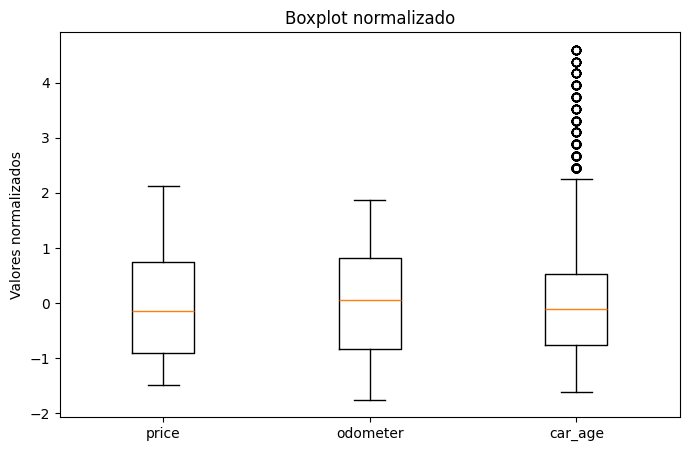

In [141]:
data_norm = []

cols = ["price", "odometer", "car_age"]

for c in cols:
    sample = df_pre_treino.select(c) \
        .dropna() \
        .sample(False, 0.05, seed=42) \
        .rdd.map(lambda x: x[0]) \
        .collect()

    sample = np.array(sample)

    std = sample.std()

    if std != 0:
        sample = (sample - sample.mean()) / std
    else:
        sample = sample - sample.mean()  # evita divisão por zero

    data_norm.append(sample)

plt.figure(figsize=(8,5))
plt.boxplot(data_norm)
plt.xticks(range(1, len(cols)+1), cols)
plt.title("Boxplot normalizado")
plt.ylabel("Valores normalizados")
plt.show()

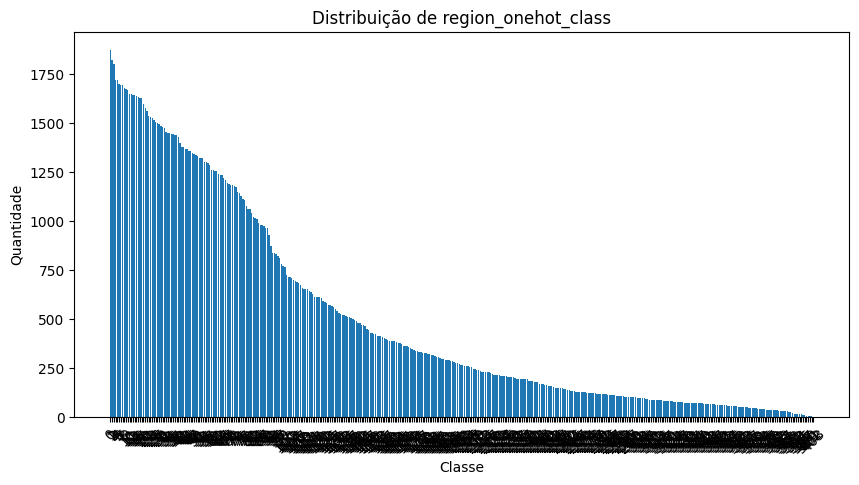

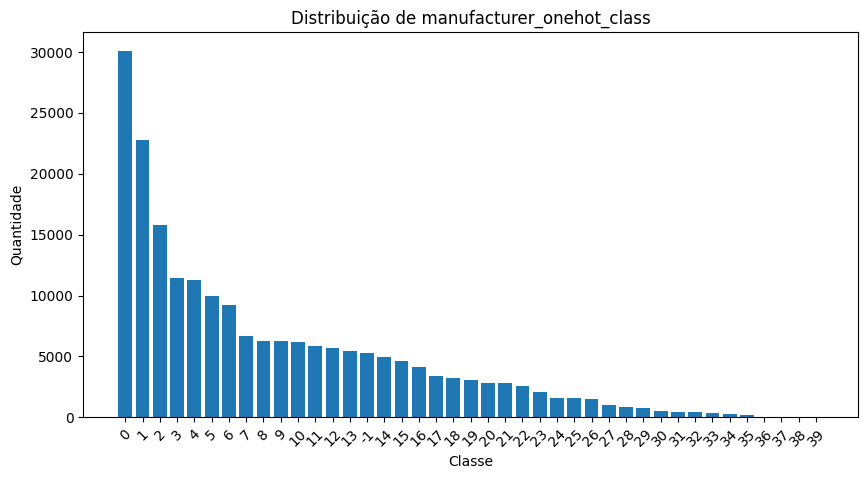

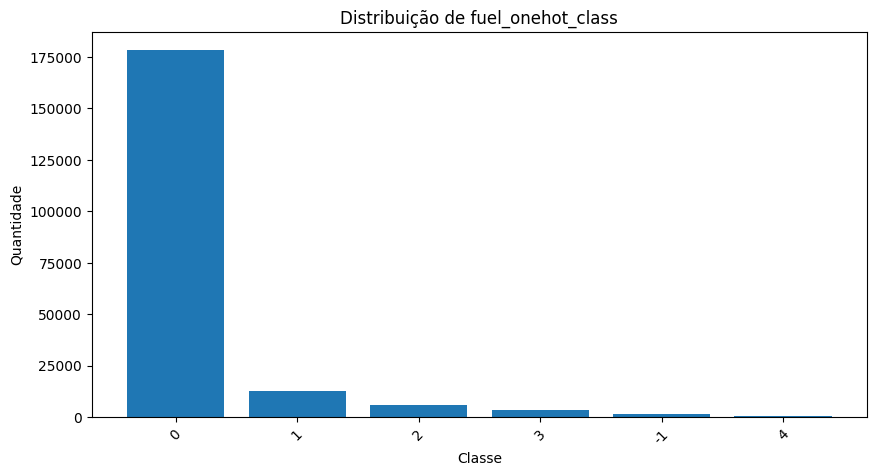

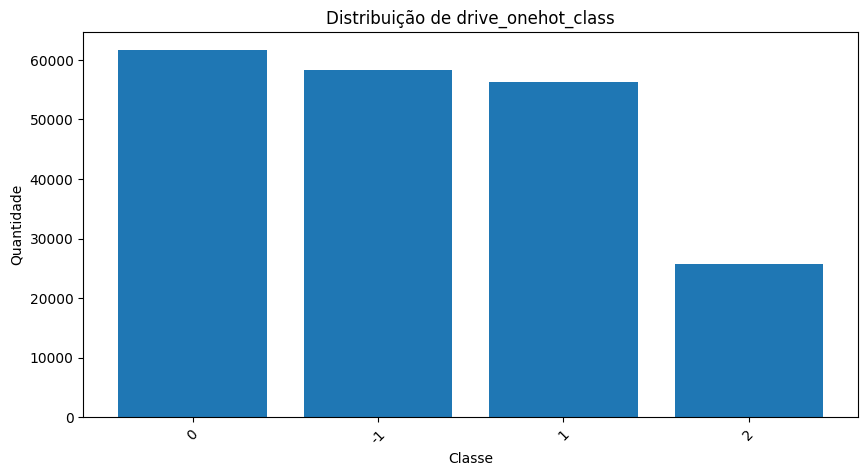

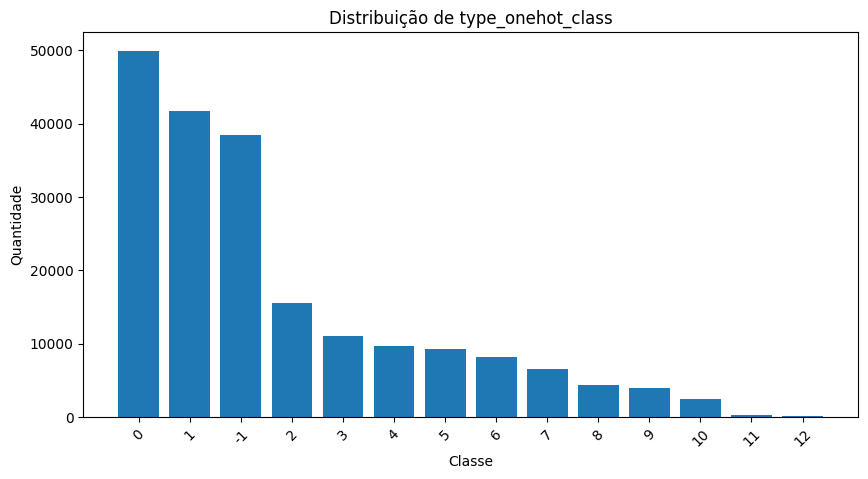

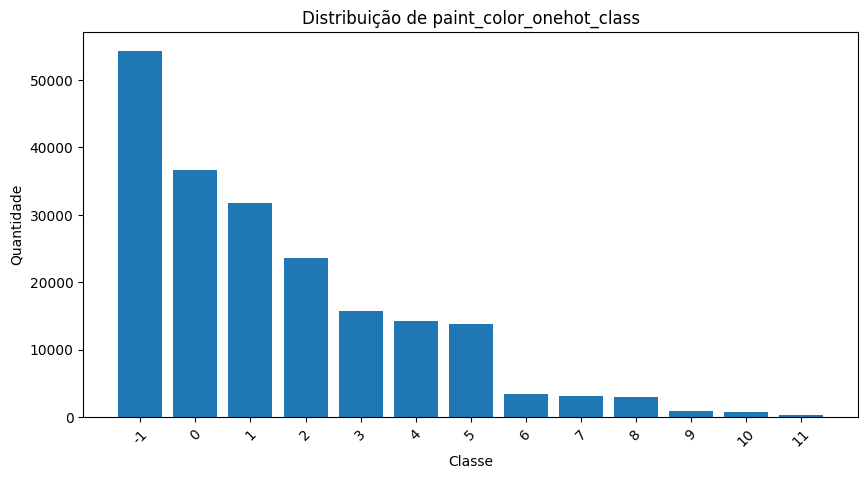

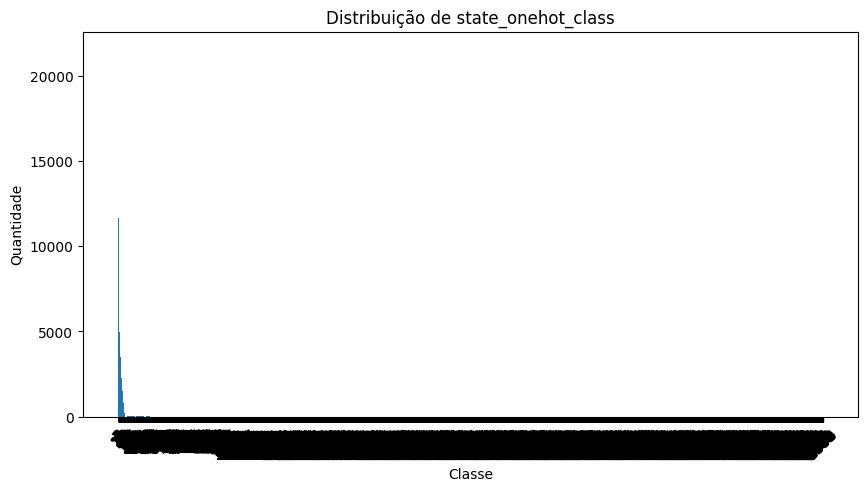

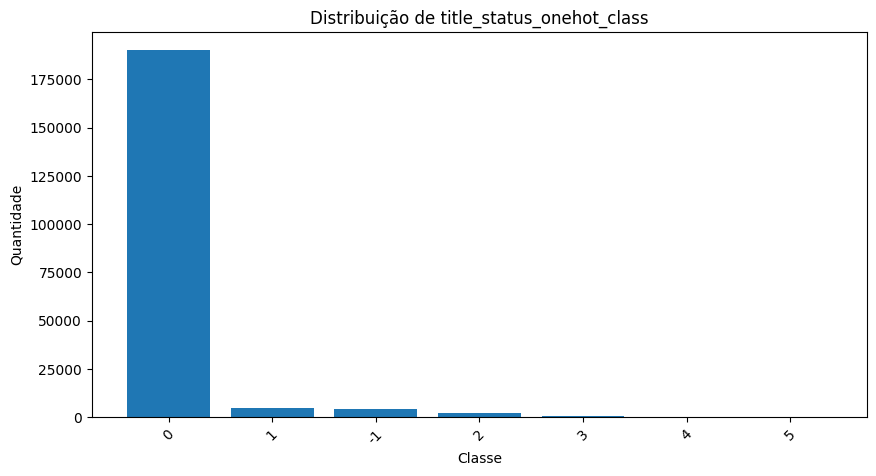

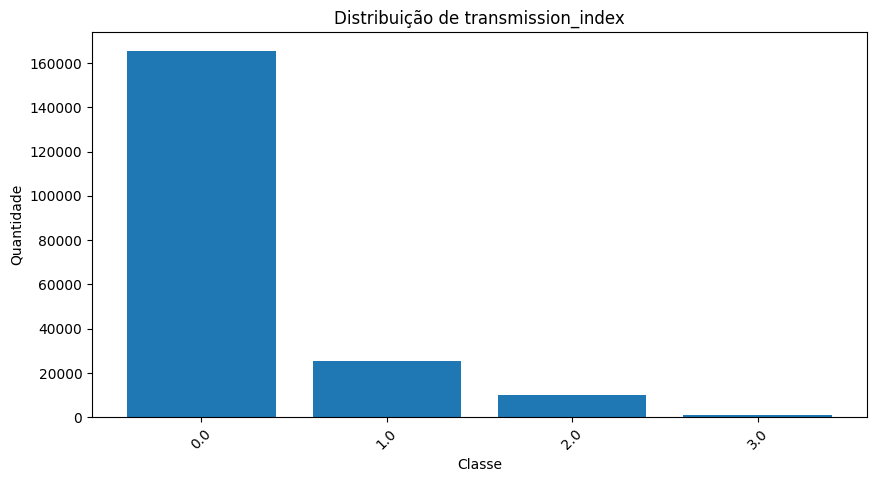

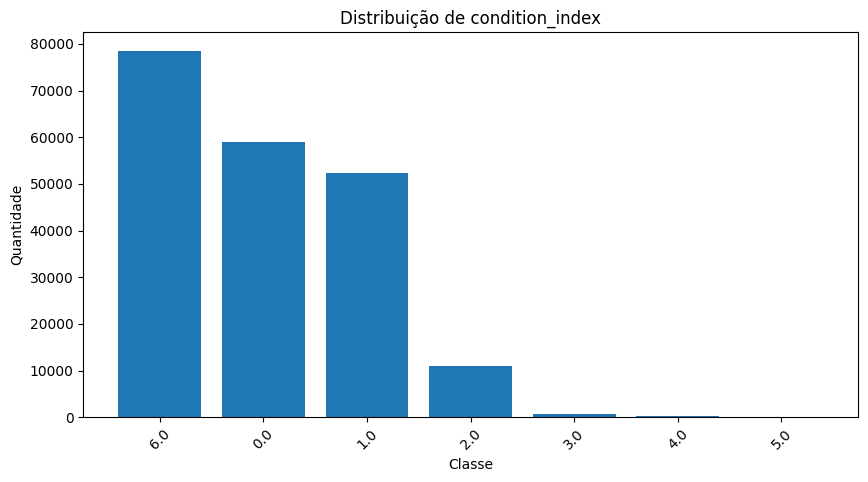

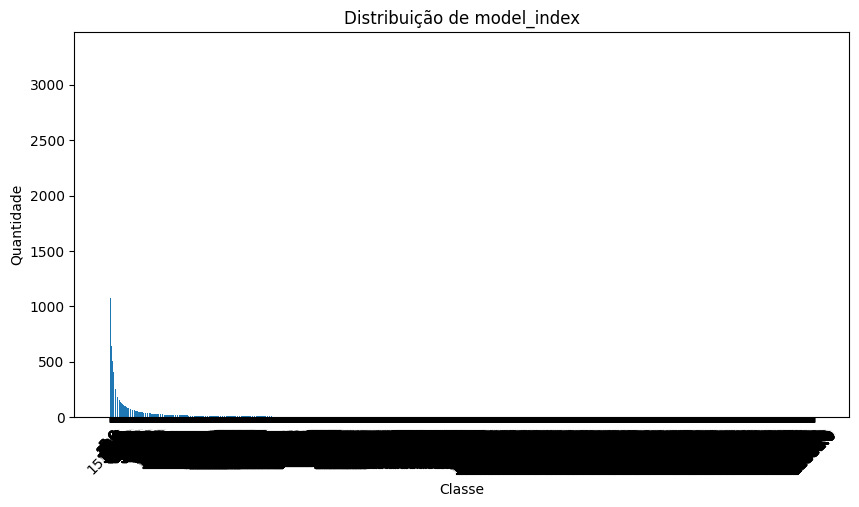

In [142]:

# Converte vetor one-hot para índice da posição ativa
def onehot_to_index(v):
    if v is None:
        return None
    arr = v.toArray()
    if arr.sum() == 0:
        return -1
    return int(arr.argmax())

onehot_to_index_udf = udf(onehot_to_index, IntegerType())

onehot_cols = [
    "region_onehot",
    "manufacturer_onehot",
    "fuel_onehot",
    "drive_onehot",
    "type_onehot",
    "paint_color_onehot",
    "state_onehot",
    "title_status_onehot"
]

index_cols = [
    "transmission_index",
    "condition_index",
    "model_index"
]

df_plot = df_pre_treino

for c in onehot_cols:
    df_plot = df_plot.withColumn(c + "_class", onehot_to_index_udf(col(c)))

plot_cols = [c + "_class" for c in onehot_cols] + index_cols

for c in plot_cols:
    data = df_plot.groupBy(c) \
        .count() \
        .orderBy("count", ascending=False) \
        .collect()

    x = [str(row[c]) for row in data]
    y = [row["count"] for row in data]

    plt.figure(figsize=(10, 5))
    plt.bar(x, y)
    plt.title(f"Distribuição de {c}")
    plt.xlabel("Classe")
    plt.ylabel("Quantidade")
    plt.xticks(rotation=45)
    plt.show()

In [169]:
from pyspark.sql.functions import col, udf, isnan
from pyspark.sql.types import IntegerType
import matplotlib.pyplot as plt
import numpy as np

def onehot_to_index(v):
    if v is None:
        return None

    arr = v.toArray()

    if arr.sum() == 0:
        return -1

    return int(arr.argmax())

onehot_to_index_udf = udf(onehot_to_index, IntegerType())

df_corr = df_pre_treino

onehot_cols = [
    "manufacturer_onehot",
    "drive_onehot",
    "type_onehot",
    "paint_color_onehot"
]

for c in onehot_cols:
    df_corr = df_corr.withColumn(
        c + "_class",
        onehot_to_index_udf(col(c))
    )

corr_cols = [
    "car_age",
    "odometer",
    "lat",
    "long",
    "manufacturer_onehot_class",
    "transmission_index",
    "drive_onehot_class",
    "type_onehot_class",
    "paint_color_onehot_class",
    "condition_index"
]

cols_necessarias = ["price"] + corr_cols

df_corr = df_corr.dropna(subset=cols_necessarias)

for c in cols_necessarias:
    df_corr = df_corr.filter(~isnan(col(c)))

correlations = []

for c in corr_cols:
    corr_value = df_corr.stat.corr("price", c)

    if corr_value is None:
        corr_value = 0.0

    correlations.append(corr_value)

corr_matrix = np.array([correlations])

plt.figure(figsize=(16, 4))
plt.imshow(corr_matrix, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlação com price")

plt.xticks(
    ticks=np.arange(len(corr_cols)),
    labels=corr_cols,
    rotation=45,
    ha="right"
)

plt.yticks([0], ["price"])
plt.title("Mapa de Correlação das Features com o Preço")

for i, value in enumerate(correlations):
    plt.text(
        i,
        0,
        f"{value:.2f}",
        ha="center",
        va="center"
    )

plt.tight_layout()
plt.show()

{"ts": "2026-05-03 13:42:33.985", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[DIVIDE_BY_ZERO] Division by zero. Use `try_divide` to tolerate divisor being 0 and return NULL instead. If necessary set \"spark.sql.ansi.enabled\" to \"false\" to bypass this error. SQLSTATE: 22012", "context": {"file": "java.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke0(Native Method)", "line": "", "fragment": "corr", "errorClass": "DIVIDE_BY_ZERO"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o31063.corr.\n: org.apache.spark.SparkArithmeticException: [DIVIDE_BY_ZERO] Division by zero. Use `try_divide` to tolerate divisor being 0 and return NULL instead. If necessary set \"spark.sql.ansi.enabled\" to \"false\" to bypass this error. SQLSTATE: 22012\n== DataFrame ==\n\"corr\" was called from\njava.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke0(Native Method)\n\n\tat org.apache.spark.sql.errors.QueryExecutionErrors$.divideByZe

ArithmeticException: [DIVIDE_BY_ZERO] Division by zero. Use `try_divide` to tolerate divisor being 0 and return NULL instead. If necessary set "spark.sql.ansi.enabled" to "false" to bypass this error. SQLSTATE: 22012
== DataFrame ==
"corr" was called from
java.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke0(Native Method)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Vamos selecionar as colunas que mapeamos para índices e as numéricas
# para ver a correlação direta com o preço
columns_for_corr = [
    'price', 'car_age', 'odometer', 'lat', 'long',
    'manufacturer_onehot_class', 'transmission_index',
    'drive_onehot_class', 'type_onehot_class', 'condition_index'
]

# Convertendo uma amostra para pandas para visualização rápida de correlação
pandas_corr = df_corr.select(columns_for_corr).sample(False, 0.1).toPandas()
corr_matrix = pandas_corr.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', center=0)
plt.title("Matriz de Correlação com o Preço")
plt.show()

In [144]:
from pyspark.sql.functions import col, udf
from pyspark.sql.types import DoubleType

# Garante que a UDF para ler os vetores OneHot esteja definida
get_index = udf(lambda v: float(v.indices[0]) if len(v.indices) > 0 else -1.0, DoubleType())

# Combinação de todos os filtros em uma única operação
df_pre_treino = df_pre_treino \
    .withColumn("paint_temp_idx", get_index(col("paint_color_onehot"))) \
    .withColumn("drive_temp_idx", get_index(col("drive_onehot"))) \
    .withColumn("type_temp_idx", get_index(col("type_onehot"))) \
    .filter(
        (~col("paint_temp_idx").isin([5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0])) &
        (~col("drive_temp_idx").isin([2.0])) &
        (~col("condition_index").isin([0.0, 2.0, 3.0, 4.0, 5.0])) &
        (~col("transmission_index").isin([1.0, 2.0, 3.0])) &
        (~col("type_temp_idx").isin([2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0]))
    ) \
    .drop("paint_temp_idx", "drive_temp_idx", "type_temp_idx")

# Opcional: Verifique o resultado
print(f"Linhas após filtros: {df_pre_treino.count()}")

Linhas após filtros: 56772


In [ ]:

# Converte vetor one-hot para índice da posição ativa
def onehot_to_index(v):
    if v is None:
        return None
    arr = v.toArray()
    if arr.sum() == 0:
        return -1
    return int(arr.argmax())

onehot_to_index_udf = udf(onehot_to_index, IntegerType())

onehot_cols = [
    "drive_onehot",
    "type_onehot",

]

index_cols = [
    "transmission_index",
    "condition_index",
]

df_plot = df_pre_treino

for c in onehot_cols:
    df_plot = df_plot.withColumn(c + "_class", onehot_to_index_udf(col(c)))

plot_cols = [c + "_class" for c in onehot_cols] + index_cols

for c in plot_cols:
    data = df_plot.groupBy(c) \
        .count() \
        .orderBy("count", ascending=False) \
        .collect()

    x = [str(row[c]) for row in data]
    y = [row["count"] for row in data]

    plt.figure(figsize=(10, 5))
    plt.bar(x, y)
    plt.title(f"Distribuição de {c}")
    plt.xlabel("Classe")
    plt.ylabel("Quantidade")
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
data_norm = []

cols = ["price", "odometer", "car_age"]

for c in cols:
    sample = df_pre_treino.select(c) \
        .dropna() \
        .sample(False, 0.05, seed=42) \
        .rdd.map(lambda x: x[0]) \
        .collect()

    sample = np.array(sample)

    std = sample.std()

    if std != 0:
        sample = (sample - sample.mean()) / std
    else:
        sample = sample - sample.mean()  # evita divisão por zero

    data_norm.append(sample)

plt.figure(figsize=(8,5))
plt.boxplot(data_norm)
plt.xticks(range(1, len(cols)+1), cols)
plt.title("Boxplot normalizado")
plt.ylabel("Valores normalizados")
plt.show()

Treinamento de Random Forest

In [170]:
# Lista dos atributos que você definiu (Features)
feature_cols = [
    "car_age",
    "odometer"
]

# Assembler: agrupa tudo em uma coluna chamada 'features'
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# Transforma o DataFrame filtrado
df_model = assembler.transform(df_pre_treino).select("features", "price")

In [171]:
# Lista de colunas que não podem ser nulas para o treino
cols_to_check = [
    "car_age",
    "odometer"
]

# Remove as linhas que possuem null em qualquer uma dessas colunas
df_pre_treino_clean = df_pre_treino.dropna(subset=cols_to_check)

# Agora use o df_pre_treino_clean no seu transform
df_model = assembler.transform(df_pre_treino_clean).select("features", "price")

In [172]:
df_model.count()

56772

In [173]:
# 80% para treino e 20% para teste
train_data, test_data = df_model.randomSplit([0.8, 0.2], seed=42)

In [174]:
try:
    df_pre_treino.unpersist()
except:
    pass

train_data_repartitioned = train_data.repartition(8)

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="price",
    numTrees=110,
    maxDepth=13,
    seed=42
)

model = rf.fit(train_data_repartitioned)

In [175]:
# Previsões no conjunto de teste
predictions = model.transform(test_data)

# Avaliadores
evaluator_rmse = RegressionEvaluator(labelCol="price", predictionCol="prediction", metricName="rmse")
evaluator_r2 = RegressionEvaluator(labelCol="price", predictionCol="prediction", metricName="r2")

rmse = evaluator_rmse.evaluate(predictions)
r2 = evaluator_r2.evaluate(predictions)

print(f"RMSE (Erro médio): {rmse:.2f}")
print(f"R² (Precisão do modelo): {r2:.2f}")

# Mostrar as primeiras comparações entre Real e Previsto
predictions.select("price", "prediction").show(10)

RMSE (Erro médio): 5684.26
R² (Precisão do modelo): 0.41
+-------+------------------+
|  price|        prediction|
+-------+------------------+
|28709.0|26597.212533796708|
|25997.0|24884.507344161208|
|20995.0|24884.507344161208|
|31968.0|23506.474370382715|
|27995.0|23506.474370382715|
|24998.0|22386.768779267382|
|26991.0|22386.768779267382|
|27995.0|22386.768779267382|
|16500.0|23740.870822514145|
|21988.0|23740.870822514145|
+-------+------------------+
only showing top 10 rows


Regressão Linear

In [153]:
from pyspark.sql.functions import col, isnan
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# =========================
# 1. Features usadas
# =========================

feature_cols = [
    "car_age",
    "odometer",
    "lat",
    "long",
    "manufacturer_onehot",
    "drive_onehot",
    "paint_color_onehot",
    "condition_index"
]

# =========================
# 2. Limpar nulos e NaN antes do assembler
# =========================

df_lr = df_pre_treino.dropna(subset=[
    "price",
    "car_age",
    "odometer",
    "lat",
    "long",
    "condition_index"
])

df_lr = df_lr.filter(
    ~isnan(col("price")) &
    ~isnan(col("car_age")) &
    ~isnan(col("odometer")) &
    ~isnan(col("lat")) &
    ~isnan(col("long")) &
    ~isnan(col("condition_index"))
)

# =========================
# 3. Recriar features do zero
# =========================

assembler_lr = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features",
    handleInvalid="skip"
)

df_lr = assembler_lr.transform(df_lr)

# =========================
# 4. Separar treino/teste
# =========================

train_lr, test_lr = df_lr.randomSplit([0.8, 0.2], seed=42)

# =========================
# 5. Regressão Linear mais estável
# =========================

lr = LinearRegression(
    featuresCol="features",
    labelCol="price",
    predictionCol="prediction",
    maxIter=50,
    regParam=0.5,
    elasticNetParam=0.0,
    standardization=True
)

lr_model = lr.fit(train_lr)

lr_predictions = lr_model.transform(test_lr)

# Remove previsões NaN, se ainda sobrar alguma
lr_predictions = lr_predictions.filter(~isnan(col("prediction")))

lr_predictions.select("price", "prediction").show(20)

# =========================
# 6. Avaliação
# =========================

evaluator_rmse = RegressionEvaluator(
    labelCol="price",
    predictionCol="prediction",
    metricName="rmse"
)

evaluator_mae = RegressionEvaluator(
    labelCol="price",
    predictionCol="prediction",
    metricName="mae"
)

evaluator_r2 = RegressionEvaluator(
    labelCol="price",
    predictionCol="prediction",
    metricName="r2"
)

print("====== REGRESSÃO LINEAR ======")
print("RMSE:", evaluator_rmse.evaluate(lr_predictions))
print("MAE:", evaluator_mae.evaluate(lr_predictions))
print("R²:", evaluator_r2.evaluate(lr_predictions))

+-----+----------+
|price|prediction|
+-----+----------+
+-----+----------+

====== REGRESSÃO LINEAR ======


IllegalArgumentException: requirement failed: Nothing has been added to this summarizer.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# ============================================================
# 1. Coletar dados do Spark para NumPy
# ============================================================

dados = df_model.select("features", "price").dropna().collect()

X = np.array([row["features"].toArray() for row in dados], dtype=np.float32)
y = np.array([row["price"] for row in dados], dtype=np.float32).reshape(-1, 1)

print("Formato X:", X.shape)
print("Formato y:", y.shape)

# ============================================================
# 2. Normalização
# ============================================================

X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_std[X_std == 0] = 1

X = (X - X_mean) / X_std

y_mean = y.mean()
y_std = y.std()

y = (y - y_mean) / y_std

# ============================================================
# 3. Separar treino/teste
# ============================================================

np.random.seed(42)
indices = np.random.permutation(len(X))

train_size = int(0.8 * len(X))

train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train = torch.tensor(X[train_idx], dtype=torch.float32)
y_train = torch.tensor(y[train_idx], dtype=torch.float32)

X_test = torch.tensor(X[test_idx], dtype=torch.float32)
y_test = torch.tensor(y[test_idx], dtype=torch.float32)

# ============================================================
# 4. Modelo de rede neural
# ============================================================

input_size = X_train.shape[1]

class RedeRegressao(nn.Module):
    def __init__(self, input_size):
        super(RedeRegressao, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

modelo = RedeRegressao(input_size)

# ============================================================
# 5. Treino
# ============================================================

criterion = nn.MSELoss()
optimizer = optim.Adam(modelo.parameters(), lr=0.001)

epochs = 100

for epoch in range(epochs):
    modelo.train()

    optimizer.zero_grad()

    y_pred = modelo(X_train)
    loss = criterion(y_pred, y_train)

    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        modelo.eval()
        with torch.no_grad():
            val_pred = modelo(X_test)
            val_loss = criterion(val_pred, y_test)

        print(f"Epoch {epoch} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")

# ============================================================
# 6. Avaliação em dólares
# ============================================================

modelo.eval()

with torch.no_grad():
    pred_norm = modelo(X_test).numpy()

pred_real = pred_norm * y_std + y_mean
y_real = y_test.numpy() * y_std + y_mean

rmse = np.sqrt(np.mean((pred_real - y_real) ** 2))
mae = np.mean(np.abs(pred_real - y_real))

print("====== REDE NEURAL PYTORCH ======")
print(f"RMSE: ${rmse:.2f}")
print(f"MAE: ${mae:.2f}")